In [10]:
from getdist import loadMCSamples
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

chain_root = "/home/weichen/cosmo_practice/chains/chains_kawas/hsc_lens_only_study"  
samples = loadMCSamples(
    chain_root,
    settings={"ignore_rows": 0.3}
)

print("# of weighted samples:", samples.weights.sum())
print("name of parameter:")
print(samples.getParamNames().list())

# of weighted samples: 384528.0
name of parameter:
['tau', 'ombh2', 'omch2', 'H0', 'ns', 'AIA', 'dm_0', 'dpz_0', 'logA', 'X1', 'X2', 'X3', 'b1', 'b2', 'b3', 'As', 'om_m', 'sigma8', 'S8_z_L1', 'S8_z_L2', 'S8_z_L3', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__test_hsc_lens.HSC_Lens']


In [11]:
p = samples.getParams()
S8 = p.sigma8 * np.sqrt(p.om_m / 0.3)

samples.addDerived(
    S8,
    name="S8",
    label="S_8"
)
samples.updateBaseStatistics()

In [12]:
params_to_report = [
    "om_m", "sigma8", "S8",
    "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]
stats = samples.getMargeStats()
rows = []

for name in params_to_report:
    par = stats.parWithName(name)
    if par is None:
        print(f"{name} not in chain")
        continue

    interval68 = par.limits[0]
    rows.append({
        "parameter": name,
        "mean": par.mean,
        "std": par.err,
        "lower_68": interval68.lower,
        "upper_68": interval68.upper
    })
posterior_table = pd.DataFrame(rows)
display(posterior_table.round(5))

,parameter,mean,std,lower_68,upper_68
0,om_m,0.33626,0.04289,0.28975,0.37902
1,sigma8,0.70588,0.06272,0.63809,0.76268
2,S8,0.74278,0.04663,0.69350,0.78537
3,AIA,-0.04511,2.86017,-5.00000,5.00000
4,dm_0,0.00030,0.01009,-0.00984,0.01039
5,dpz_0,-0.05745,0.08708,-0.14320,0.02682
6,X1,1.09943,0.17394,0.92623,1.27229
7,X2,1.24091,0.13666,1.10574,1.37714
8,X3,1.17697,0.14499,1.02029,1.30328
9,b1,2.01700,0.37344,1.59827,2.27028


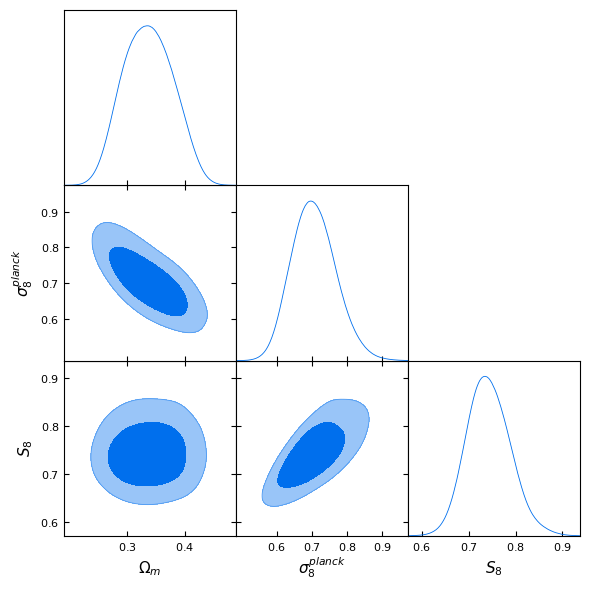

In [16]:
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False

g.triangle_plot(
    [samples],
    ["om_m", "sigma8", "S8"],
    filled=True
)

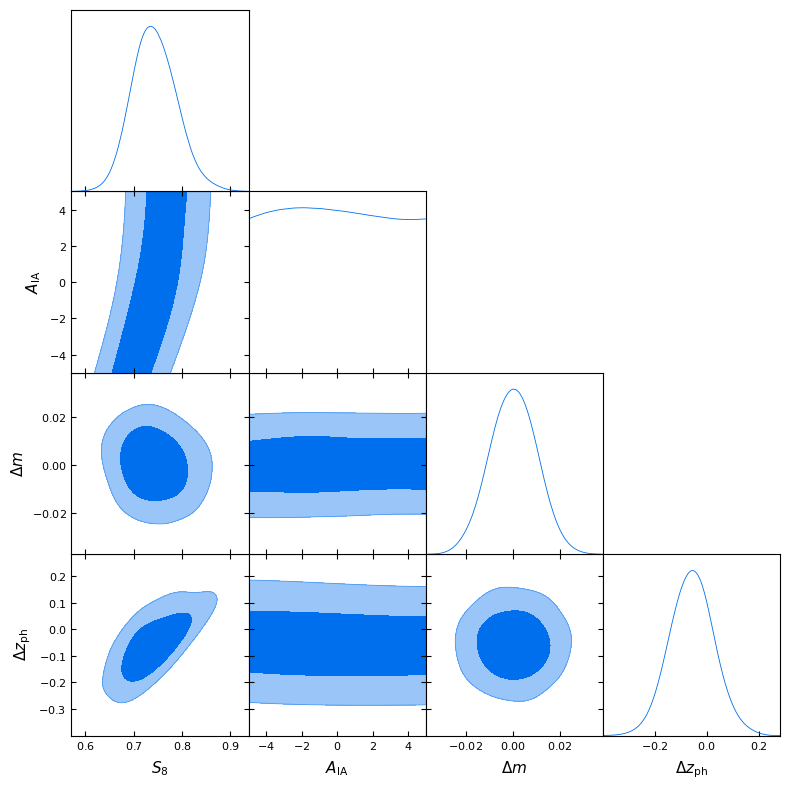

In [ ]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [samples],
    ["S8", "AIA", "dm_0", "dpz_0"],
    filled=True
)

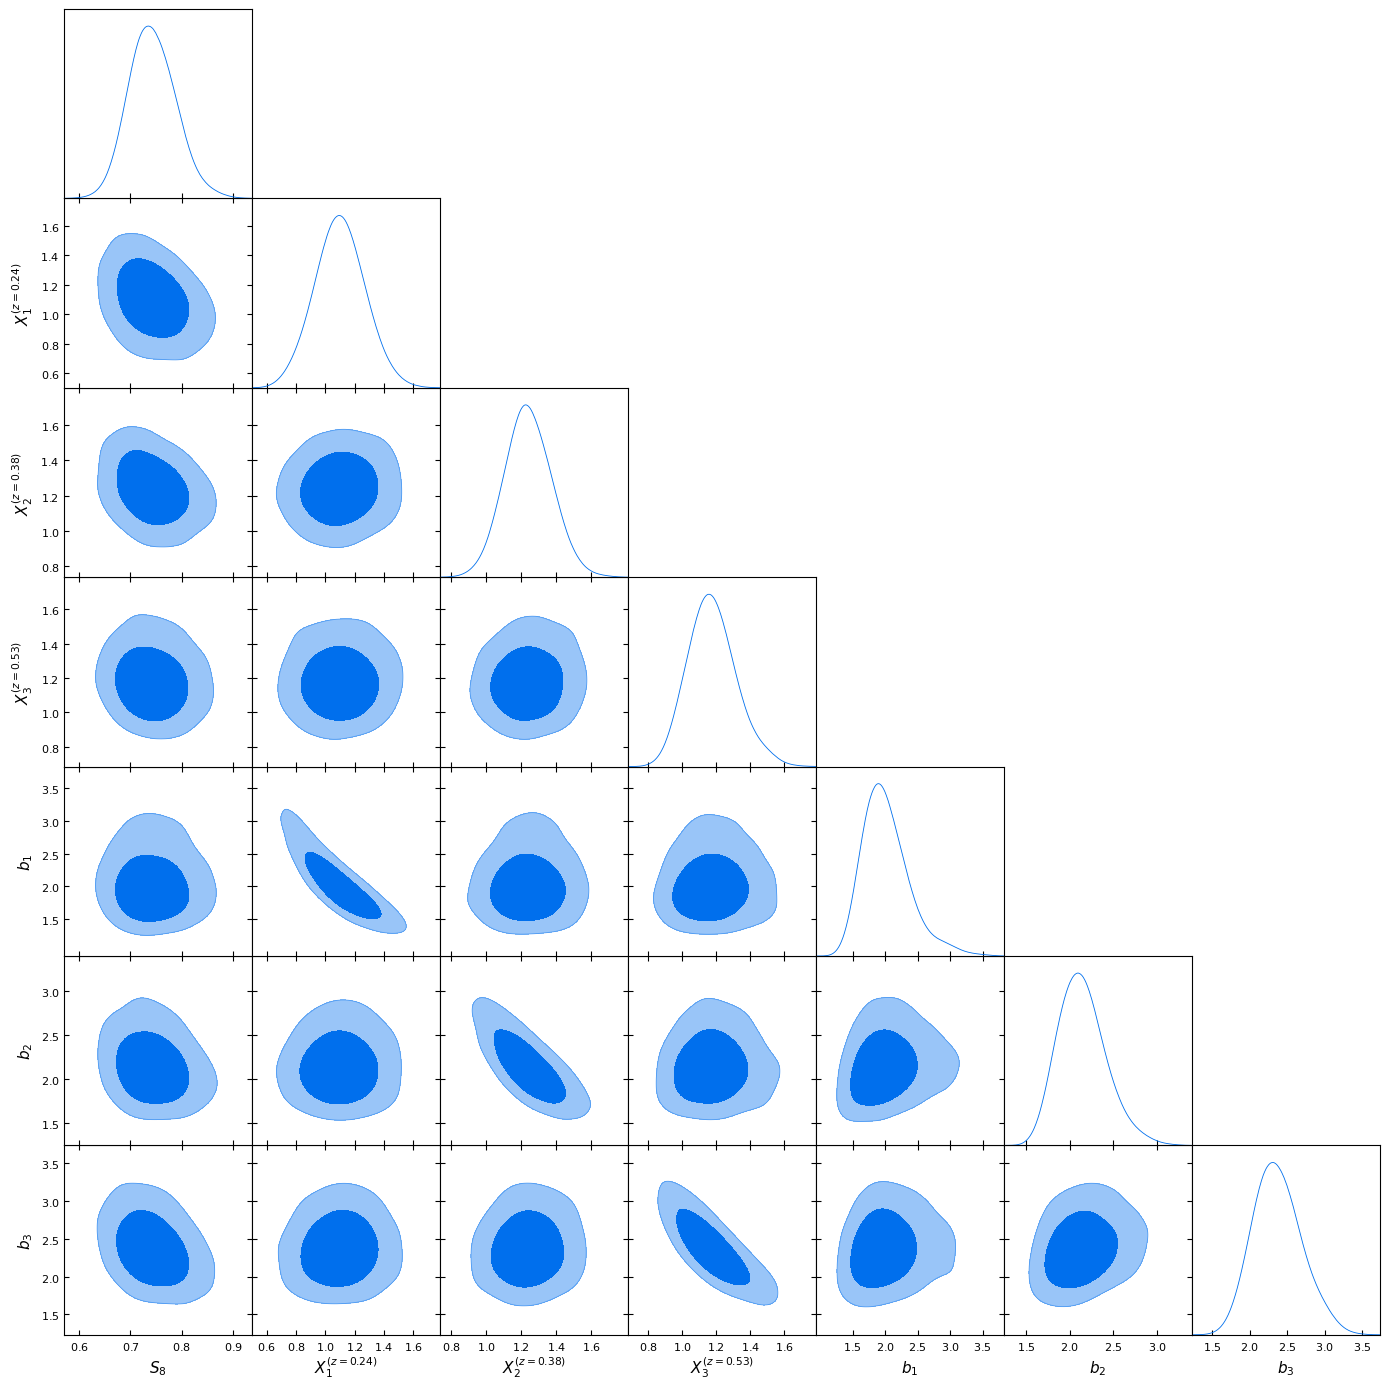

In [ ]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [samples],
    ["S8", "X1", "X2", "X3", "b1", "b2", "b3"],
    filled=True
)

In [15]:
corr_params = [
    "S8", "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]

p = samples.getParams()
values = np.column_stack([getattr(p, name) for name in corr_params])
weights = samples.weights
mean = np.average(values, axis=0, weights=weights)
centered = values - mean
cov = ((centered * weights[:, None]).T @ centered / weights.sum())

# corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
# corr_table = pd.DataFrame(
#     corr,
#     index=corr_params,
#     columns=corr_params
# )
# display(corr_table.round(2))

In [ ]:
map_values = {
    "om_m": 0.29044466,
    "sigma8": 0.78272345,
    "S8": 0.78272345 * np.sqrt(0.29044466 / 0.3),
    "AIA": -0.79407104,
    "dm_0": 0.0011879888,
    "dpz_0": -0.029562746,
    "X1": 1.0584525,
    "X2": 1.1665719,
    "X3": 1.2463822
}

comparison_rows = []
for name, map_value in map_values.items():
    par = stats.parWithName(name)

    comparison_rows.append({
        "parameter": name,
        "MAP": map_value,
        "posterior_mean": par.mean,
        "posterior_std": par.err,
        "MAP_minus_mean_in_sigma":
            (map_value - par.mean) / par.err
    })

map_posterior_comparison = pd.DataFrame(comparison_rows)
display(map_posterior_comparison.round(4))

,parameter,MAP,posterior_mean,posterior_std,MAP_minus_mean_in_sigma
0,om_m,0.2904,0.3363,0.0429,-1.0682
1,sigma8,0.7827,0.7059,0.0627,1.2252
2,S8,0.7702,0.7428,0.0466,0.5871
3,AIA,-0.7941,-0.0451,2.8602,-0.2619
4,dm_0,0.0012,0.0003,0.0101,0.0881
5,dpz_0,-0.0296,-0.0574,0.0871,0.3202
6,X1,1.0585,1.0994,0.1739,-0.2356
7,X2,1.1666,1.2409,0.1367,-0.5440
8,X3,1.2464,1.1770,0.1450,0.4787
